In [ ]:
"""
Assignment 5---- EDA


Objective:
The main goal of this assignment is to conduct a thorough exploratory analysis of the "cardiographic.csv" dataset to uncover insights, identify patterns, and understand the dataset's underlying structure. You will use statistical summaries, visualizations, and data manipulation techniques to explore the dataset comprehensively.
Dataset:
1.	LB - Likely stands for "Baseline Fetal Heart Rate (FHR)" which represents the average fetal heart rate over a period.
2.	AC - Could represent "Accelerations" in the FHR. Accelerations are usually a sign of fetal well-being.
3.	FM - May indicate "Fetal Movements" detected by the monitor.
4.	UC - Likely denotes "Uterine Contractions", which can impact the FHR pattern.
5.	DL - Could stand for "Decelerations Late" with respect to uterine contractions, which can be a sign of fetal distress.
6.	DS - May represent "Decelerations Short" or decelerations of brief duration.
7.	DP - Could indicate "Decelerations Prolonged", or long-lasting decelerations.
8.	ASTV - Might refer to "Percentage of Time with Abnormal Short Term Variability" in the FHR.
9.	MSTV - Likely stands for "Mean Value of Short Term Variability" in the FHR.
10.	ALTV - Could represent "Percentage of Time with Abnormal Long Term Variability" in the FHR.
11.	MLTV - Might indicate "Mean Value of Long Term Variability" in the FHR.


Tools and Libraries:
●	Python programming language
●	Data manipulation libraries 
●	Data visualization libraries (Matplotlib and Seaborn in Python)
●	Jupyter Notebook for documenting your analysis


Tasks:
1.	Data Cleaning and Preparation:
●	Load the dataset into a data frame or equivalent data structure.
●	Handle missing values appropriately (e.g., imputation, deletion).
●	Identify and correct any inconsistencies in data types (e.g., numerical values stored as strings).
●	Detect and treat outliers if necessary.
2.	Statistical Summary:
●	Provide a statistical summary for each variable in the dataset, including measures of central tendency (mean, median) and dispersion (standard deviation, interquartile range).
●	Highlight any interesting findings from this summary.
3.	Data Visualization:
●	Create histograms or boxplots to visualize the distributions of various numerical variables.
●	Use bar charts or pie charts to display the frequency of categories for categorical variables.
●	Generate scatter plots or correlation heatmaps to explore relationships between pairs of variables.
●	Employ advanced visualization techniques like pair plots, or violin plots for deeper insights.
4.	Pattern Recognition and Insights:
●	Identify any correlations between variables and discuss their potential implications.
●	Look for trends or patterns over time if temporal data is available.
5.	Conclusion:
●	Summarize the key insights and patterns discovered through your exploratory analysis.
●	Discuss how these findings could impact decision-making or further analyses.
Deliverables:
●	A detailed Jupyter Notebook file containing the code, visualizations, and explanations for each step of your analysis.
●	A brief report summarizing your findings, insights, and any recommendations for further analysis or actions based on the data.
"""


In [19]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)



In [2]:
# Task 1: Data Cleaning and Preparation

# Load the dataset
df = pd.read_csv('Assi_5_Cardiotocographic.csv')

print("Initial Dataset Information:")
print("-"*50)
print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nLast 5 rows:")
print(df.tail())

Initial Dataset Information:
--------------------------------------------------
Dataset Shape: (2126, 14)

First 5 rows:
           LB        AC   FM        UC        DL   DS   DP  ASTV  MSTV  ALTV  \
0  120.000000  0.000000  0.0  0.000000  0.000000  0.0  0.0  73.0   0.5  43.0   
1  132.000000  0.006380  0.0  0.006380  0.003190  0.0  0.0  17.0   2.1   0.0   
2  133.000000  0.003322  0.0  0.008306  0.003322  0.0  0.0  16.0   2.1   0.0   
3  134.000000  0.002561  0.0  0.007742  0.002561  0.0  0.0  16.0   2.4   0.0   
4  131.948232  0.006515  0.0  0.008143  0.000000  0.0  0.0  16.0   2.4   0.0   

   MLTV  Width  Tendency  NSP  
0   2.4   64.0  0.999926  2.0  
1  10.4  130.0  0.000000  1.0  
2  13.4  130.0  0.000000  1.0  
3  23.0  117.0  1.000000  1.0  
4  19.9  117.0  1.000000  1.0  

Last 5 rows:
         LB        AC        FM        UC   DL   DS   DP  ASTV  MSTV  \
2121  140.0  0.000000  0.961268  0.007426  0.0  0.0  0.0  79.0   0.2   
2122  140.0  0.000775  0.000000  0.006979  0.0  

In [3]:
# Display data types
print("\nData Types:")
print("-"*30)
print(df.dtypes)


Data Types:
------------------------------
LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object


In [4]:
# Check for missing values
print("\nMissing Values Analysis:")
print("-"*30)
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])


Missing Values Analysis:
------------------------------
          Missing Count  Missing Percentage
LB                   21            0.987770
AC                   20            0.940734
DS                   21            0.987770
DP                   21            0.987770
MLTV                 21            0.987770
Width                21            0.987770
Tendency             21            0.987770
NSP                  21            0.987770


In [5]:
# Handle missing values
print("\nHandling Missing Values:")
print("-"*30)

# Check rows with missing values before cleaning
print(f"Rows with missing values before cleaning: {df.isnull().any(axis=1).sum()}")

# Drop rows where NSP is missing (target variable)
df_clean = df.dropna(subset=['NSP'])

# For numerical columns, fill with median
numerical_cols = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Tendency']
for col in numerical_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f"Rows with missing values after cleaning: {df_clean.isnull().any(axis=1).sum()}")

# Display cleaned dataset info
print(f"\nCleaned Dataset Shape: {df_clean.shape}")
print(f"\nCleaned Dataset Info:")
df_clean.info()


Handling Missing Values:
------------------------------
Rows with missing values before cleaning: 21
Rows with missing values after cleaning: 0

Cleaned Dataset Shape: (2105, 14)

Cleaned Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 2105 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2105 non-null   float64
 2   FM        2105 non-null   float64
 3   UC        2105 non-null   float64
 4   DL        2105 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2105 non-null   float64
 8   MSTV      2105 non-null   float64
 9   ALTV      2105 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 246.7 KB


In [6]:
# Identify and correct inconsistencies in data types
print("\nData Type Verification:")
print("-"*30)

# Check for non-numeric values in numeric columns
for col in numerical_cols:
    if col in df_clean.columns:
        # Convert to numeric, coercing errors
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        
        # Check for any remaining NaN after coercion
        nan_count = df_clean[col].isnull().sum()
        if nan_count > 0:
            print(f"Column '{col}' has {nan_count} non-numeric values converted to NaN")
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# NSP should be integer (Fetal State Class)
# 1 = Normal, 2 = Suspect, 3 = Pathologic
df_clean['NSP'] = pd.to_numeric(df_clean['NSP'], errors='coerce')
df_clean['NSP'] = df_clean['NSP'].fillna(df_clean['NSP'].median()).round().astype(int)

print("\nAfter type conversion:")
print(df_clean.dtypes)


Data Type Verification:
------------------------------

After type conversion:
LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP           int64
dtype: object


In [7]:
# Detect and treat outliers using IQR method
print("\nOutlier Detection and Treatment:")
print("-"*30)

outlier_summary = {}
for col in numerical_cols:
    if col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_percent = (outlier_count / len(df_clean)) * 100
        
        outlier_summary[col] = {
            'Outlier Count': outlier_count,
            'Outlier Percentage': f"{outlier_percent:.2f}%",
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound
        }
        
        # Cap outliers (winsorization)
        df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)


Outlier Detection and Treatment:
------------------------------
         Outlier Count Outlier Percentage Lower Bound Upper Bound
LB                  10              0.48%       105.0       161.0
AC                  39              1.85%   -0.008475    0.014124
FM                 343             16.29%   -0.003831    0.006386
UC                  13              0.62%   -0.005209    0.013583
DL                 124              5.89%   -0.004934    0.008224
DS                 120              5.70%         0.0         0.0
DP                 284             13.49%         0.0         0.0
ASTV                10              0.48%       -11.5       104.5
MSTV                78              3.71%        -0.8         3.2
ALTV               317             15.06%       -16.5        27.5
MLTV                81              3.85%       -4.85       20.35
Width               10              0.48%       -57.5       194.5
Tendency            10              0.48%        -1.5         2.5


In [20]:
# Task 2: Statistical Summary

# Comprehensive statistical summary
print("\nDetailed Statistical Summary for All Variables:")
print("-"*50)
statistical_summary = df_clean[numerical_cols].describe().round(2)
print(statistical_summary)

# Additional statistics
print("\nAdditional Statistical Measures:")
print("-"*50)
additional_stats = pd.DataFrame({
    'Skewness': df_clean[numerical_cols].skew().round(3),
    'Kurtosis': df_clean[numerical_cols].kurtosis().round(3),
    'Variance': df_clean[numerical_cols].var().round(3)
})
print(additional_stats)

# NSP distribution (categorical summary)
print("\nNSP (Fetal State Class) Distribution:")
print("-"*30)
nsp_counts = df_clean['NSP'].value_counts().sort_index()
nsp_percent = (nsp_counts / len(df_clean)) * 100
nsp_summary = pd.DataFrame({
    'Count': nsp_counts,
    'Percentage': nsp_percent.round(2)
})
print(nsp_summary)
print("\nClass Labels:")
print("1 = Normal")
print("2 = Suspect")
print("3 = Pathologic")


Detailed Statistical Summary for All Variables:
--------------------------------------------------
            LB       AC       FM       UC       DL      DS      DP     ASTV  \
count  2105.00  2105.00  2105.00  2105.00  2105.00  2105.0  2105.0  2105.00   
mean    133.29     0.00     0.00     0.00     0.00     0.0     0.0    46.98   
std       9.98     0.00     0.00     0.00     0.00     0.0     0.0    17.64   
min     105.00    -0.01    -0.00    -0.01    -0.00     0.0     0.0   -11.50   
25%     126.00     0.00     0.00     0.00     0.00     0.0     0.0    32.00   
50%     133.00     0.00     0.00     0.00     0.00     0.0     0.0    49.00   
75%     140.00     0.01     0.00     0.01     0.00     0.0     0.0    61.00   
max     161.00     0.01     0.01     0.01     0.01     0.0     0.0   104.50   

          MSTV     ALTV     MLTV    Width  Tendency  
count  2105.00  2105.00  2105.00  2105.00   2105.00  
mean      1.30     6.73     8.02    70.32      0.32  
std       0.78    10.40   

In [21]:
# Interesting findings from statistical summary

# Identify columns with high variance
high_variance_cols = additional_stats[additional_stats['Variance'] > 1000].index.tolist()
print(f"1. High Variance Variables (>1000): {high_variance_cols}")

# Identify skewed distributions
highly_skewed = additional_stats[abs(additional_stats['Skewness']) > 2].index.tolist()
print(f"2. Highly Skewed Variables (|skewness| > 2): {highly_skewed}")

# Check ALTV values
altv_stats = statistical_summary['ALTV']
print(f"3. ALTV (Abnormal Long Term Variability) shows high standard deviation: {altv_stats['std']:.2f}")

# NSP distribution insight
print(f"4. Class Distribution: {nsp_percent[1]:.1f}% Normal, {nsp_percent[2]:.1f}% Suspect, {nsp_percent[3]:.1f}% Pathologic")

# Check for potential data quality issues
negative_cols = [col for col in numerical_cols if (df_clean[col] < 0).any()]
print(f"5. Columns with negative values (potential data issues): {negative_cols}")

1. High Variance Variables (>1000): ['Width']
2. Highly Skewed Variables (|skewness| > 2): []
3. ALTV (Abnormal Long Term Variability) shows high standard deviation: 10.40
4. Class Distribution: 77.4% Normal, 13.9% Suspect, 8.2% Pathologic
5. Columns with negative values (potential data issues): ['AC', 'FM', 'UC', 'DL', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Tendency']


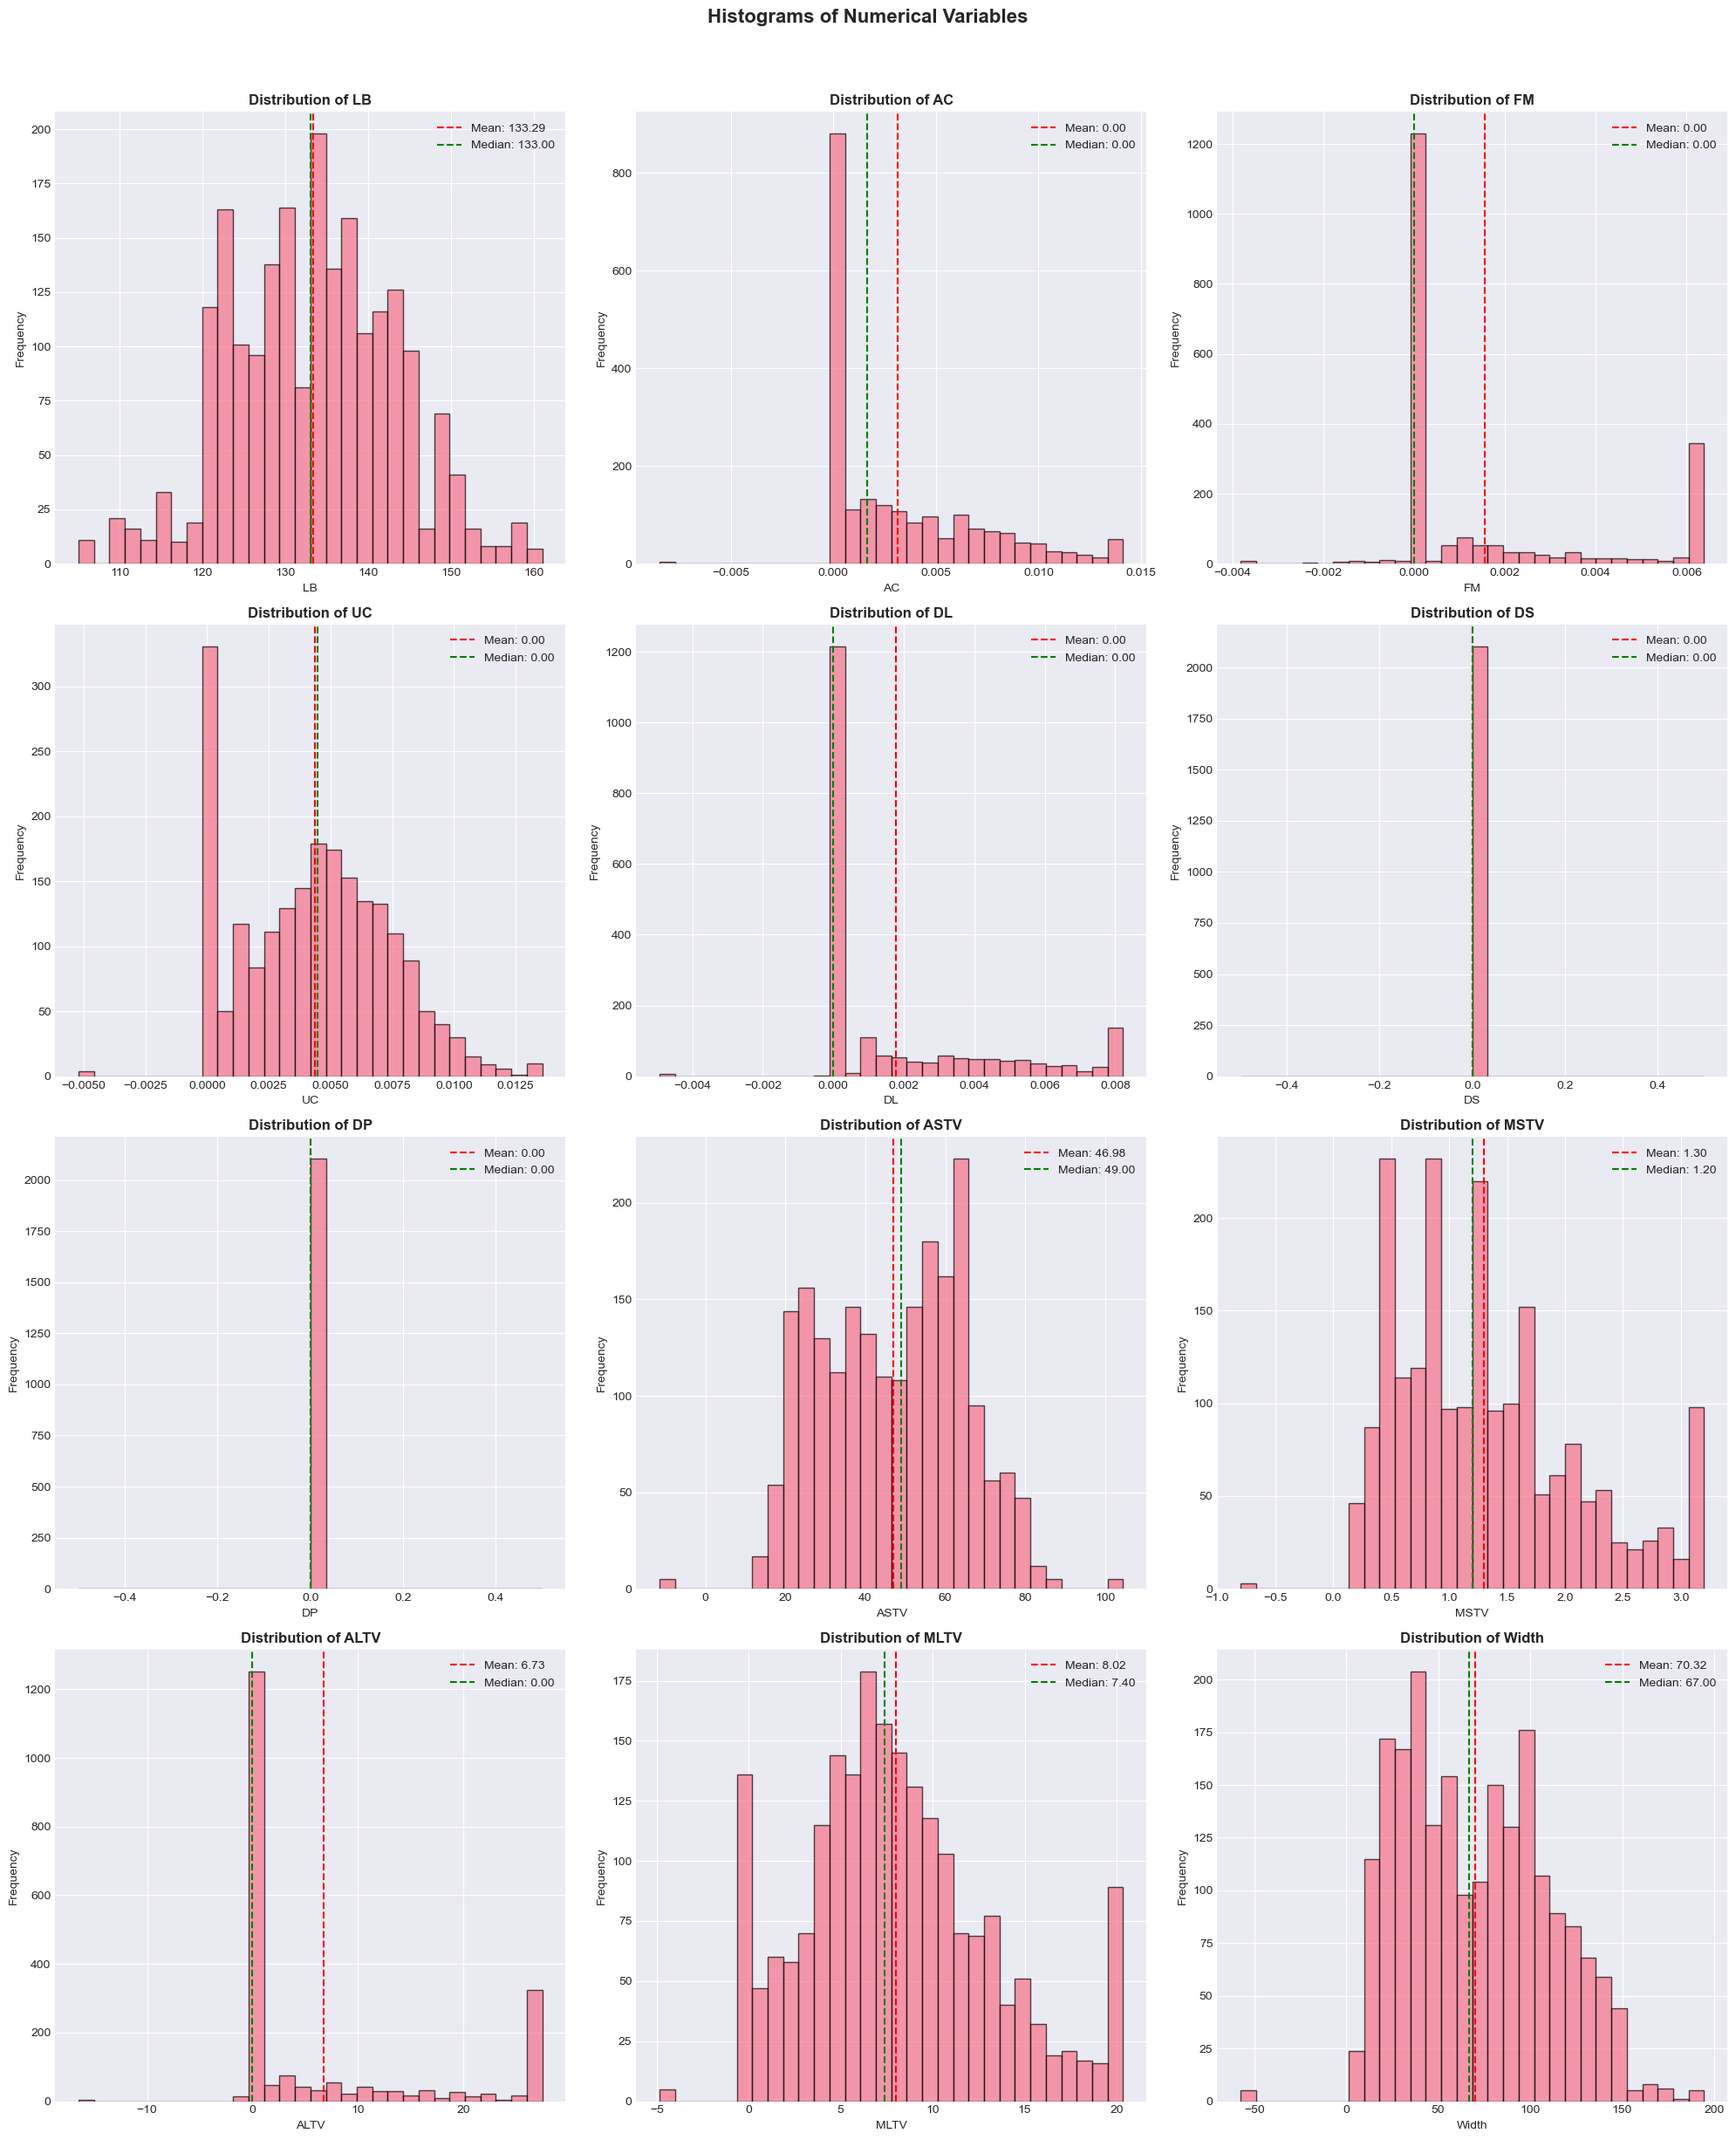

In [22]:
# Task 3: Data Visualization


# Create a figure for multiple visualizations
fig = plt.figure(figsize=(20, 24))

# 3.1 Histograms for numerical variables
for i, col in enumerate(numerical_cols[:12], 1):  # First 12 numerical columns
    ax = fig.add_subplot(4, 3, i)
    df_clean[col].hist(bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.axvline(df_clean[col].mean(), color='red', linestyle='--', label=f'Mean: {df_clean[col].mean():.2f}')
    ax.axvline(df_clean[col].median(), color='green', linestyle='--', label=f'Median: {df_clean[col].median():.2f}')
    ax.legend()

plt.suptitle('Histograms of Numerical Variables', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

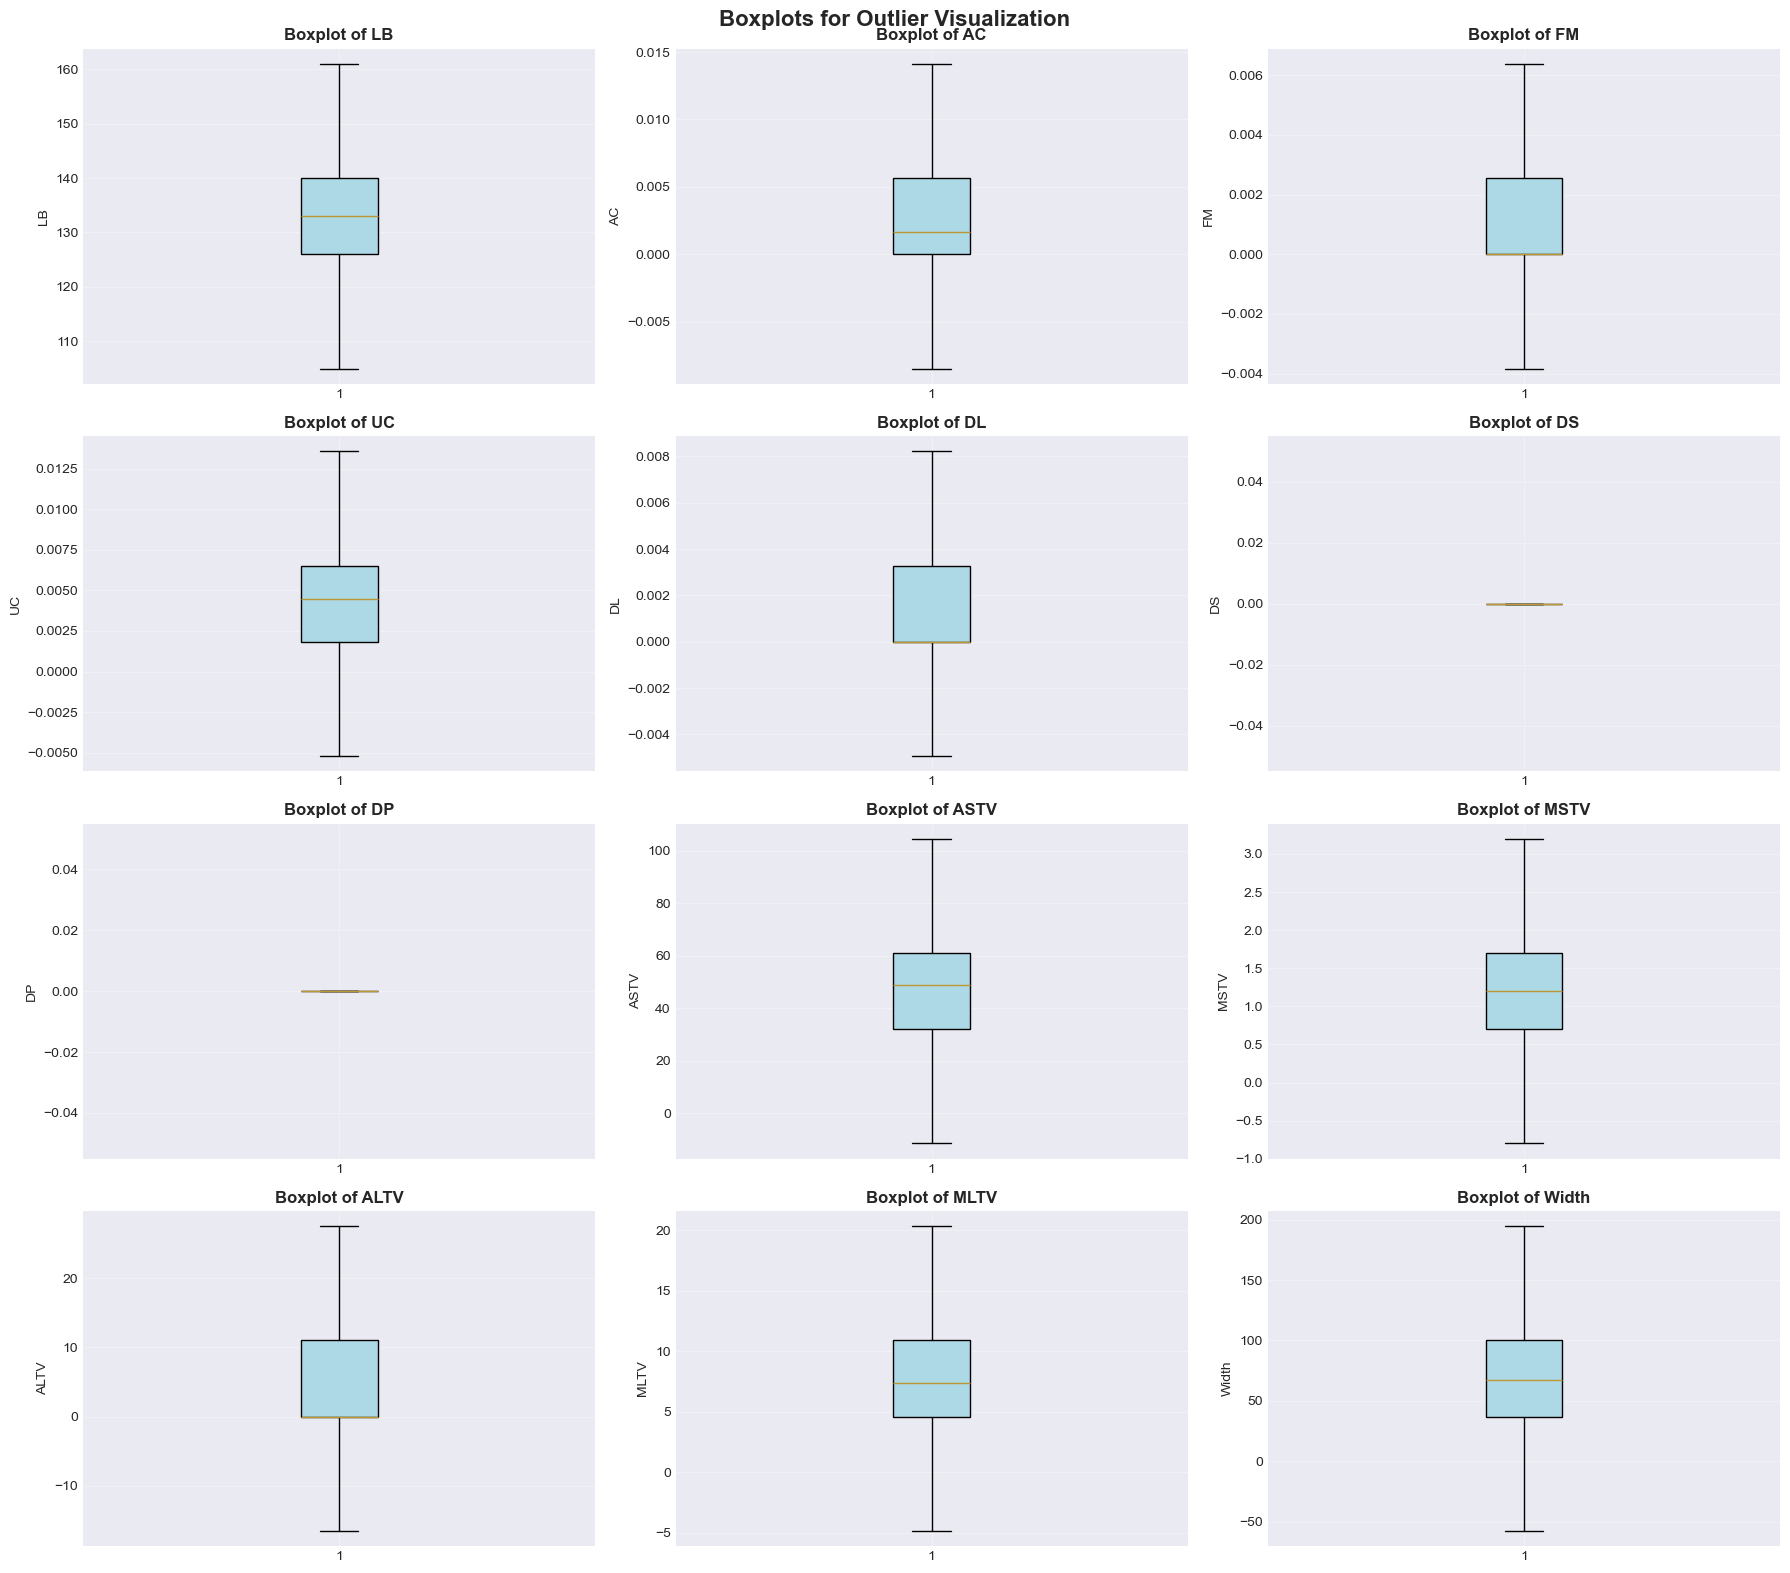

In [11]:
# Boxplots for numerical variables
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols[:12]):
    bp = axes[i].boxplot(df_clean[col], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Boxplots for Outlier Visualization', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

NameError: name 'nsp_counts' is not defined

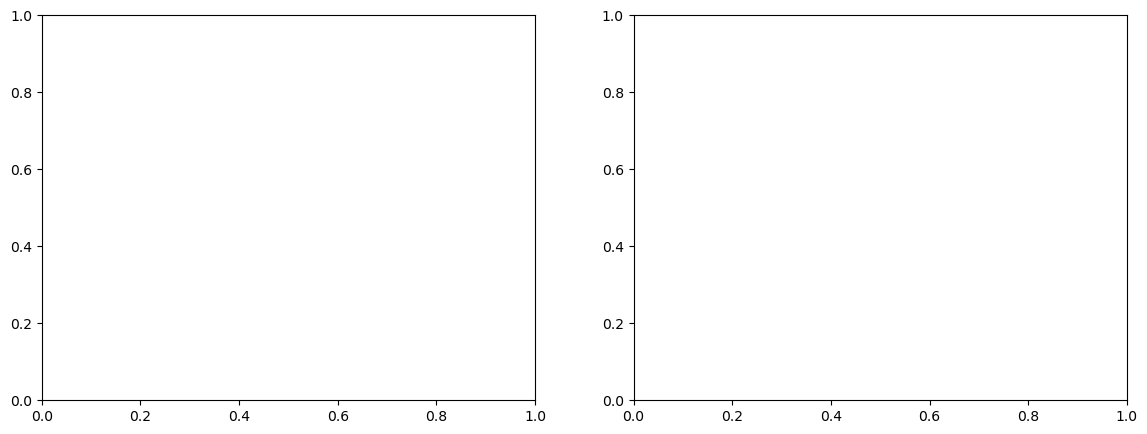

In [2]:
# Bar chart for NSP categories
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = axes[0].bar(nsp_counts.index, nsp_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribution of Fetal State Classes (NSP)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fetal State Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(['Normal (1)', 'Suspect (2)', 'Pathologic (3)'])

# Add value labels on bars
for bar, count in zip(bars, nsp_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 f'{count}\n({nsp_percent[bar.get_x()]:.1f}%)', 
                 ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(nsp_counts.values, labels=['Normal', 'Suspect', 'Pathologic'], 
            autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0.05, 0.05))
axes[1].set_title('NSP Class Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.suptitle('Fetal State Classification Distribution', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

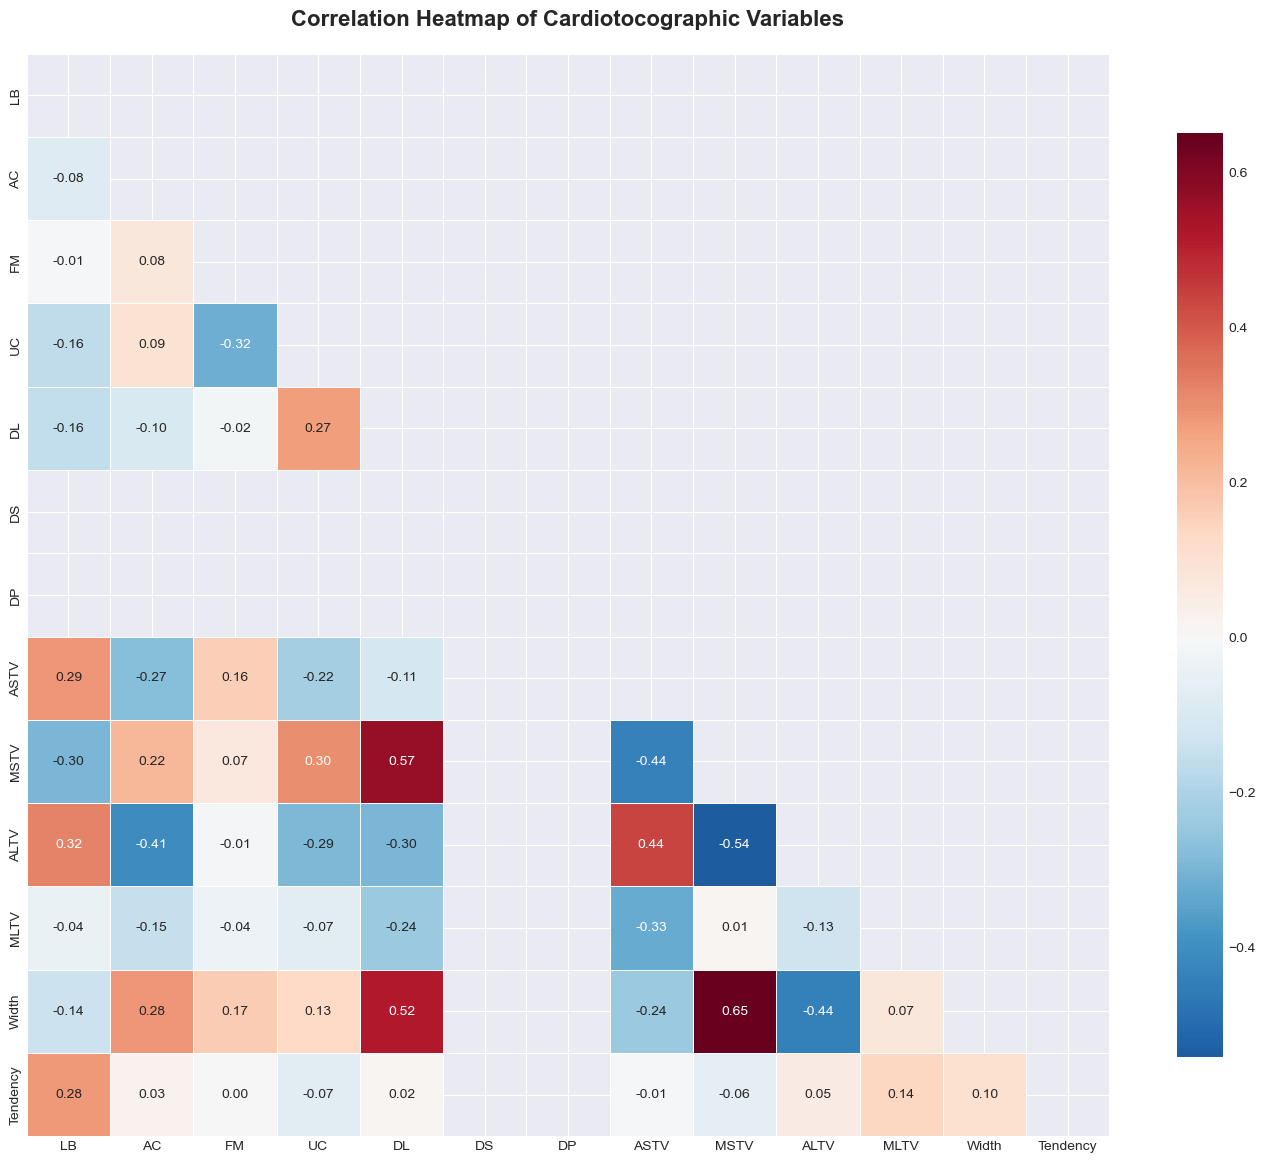

In [13]:
# Correlation Heatmap
plt.figure(figsize=(14, 12))

# Calculate correlation matrix
correlation_matrix = df_clean[numerical_cols].corr()

# Create heatmap
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title('Correlation Heatmap of Cardiotocographic Variables', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

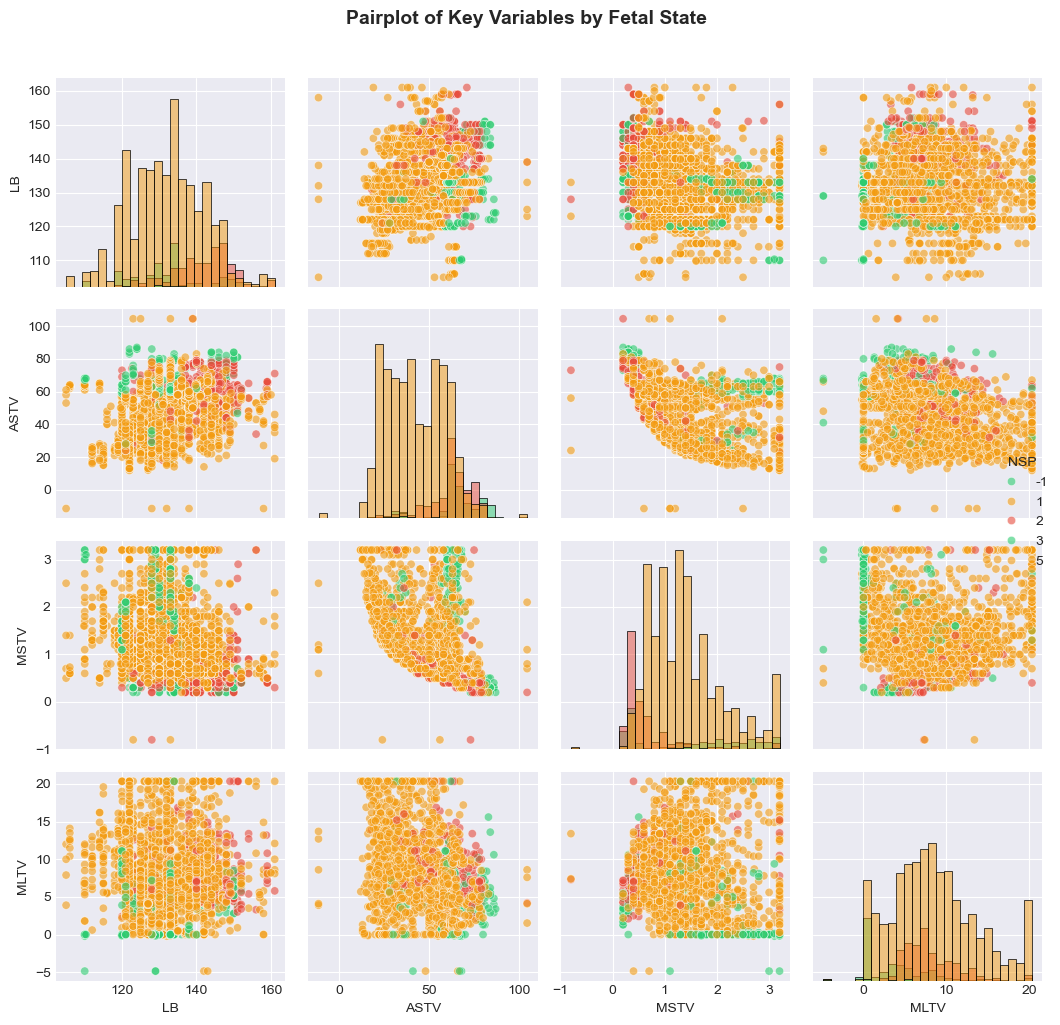

In [14]:
# Advanced visualization: Pairplot for key variables
key_vars = ['LB', 'ASTV', 'MSTV', 'MLTV', 'NSP']
sns.pairplot(df_clean[key_vars], hue='NSP', palette=colors, diag_kind='hist', 
             plot_kws={'alpha': 0.6}, diag_kws={'edgecolor': 'black'})
plt.suptitle('Pairplot of Key Variables by Fetal State', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

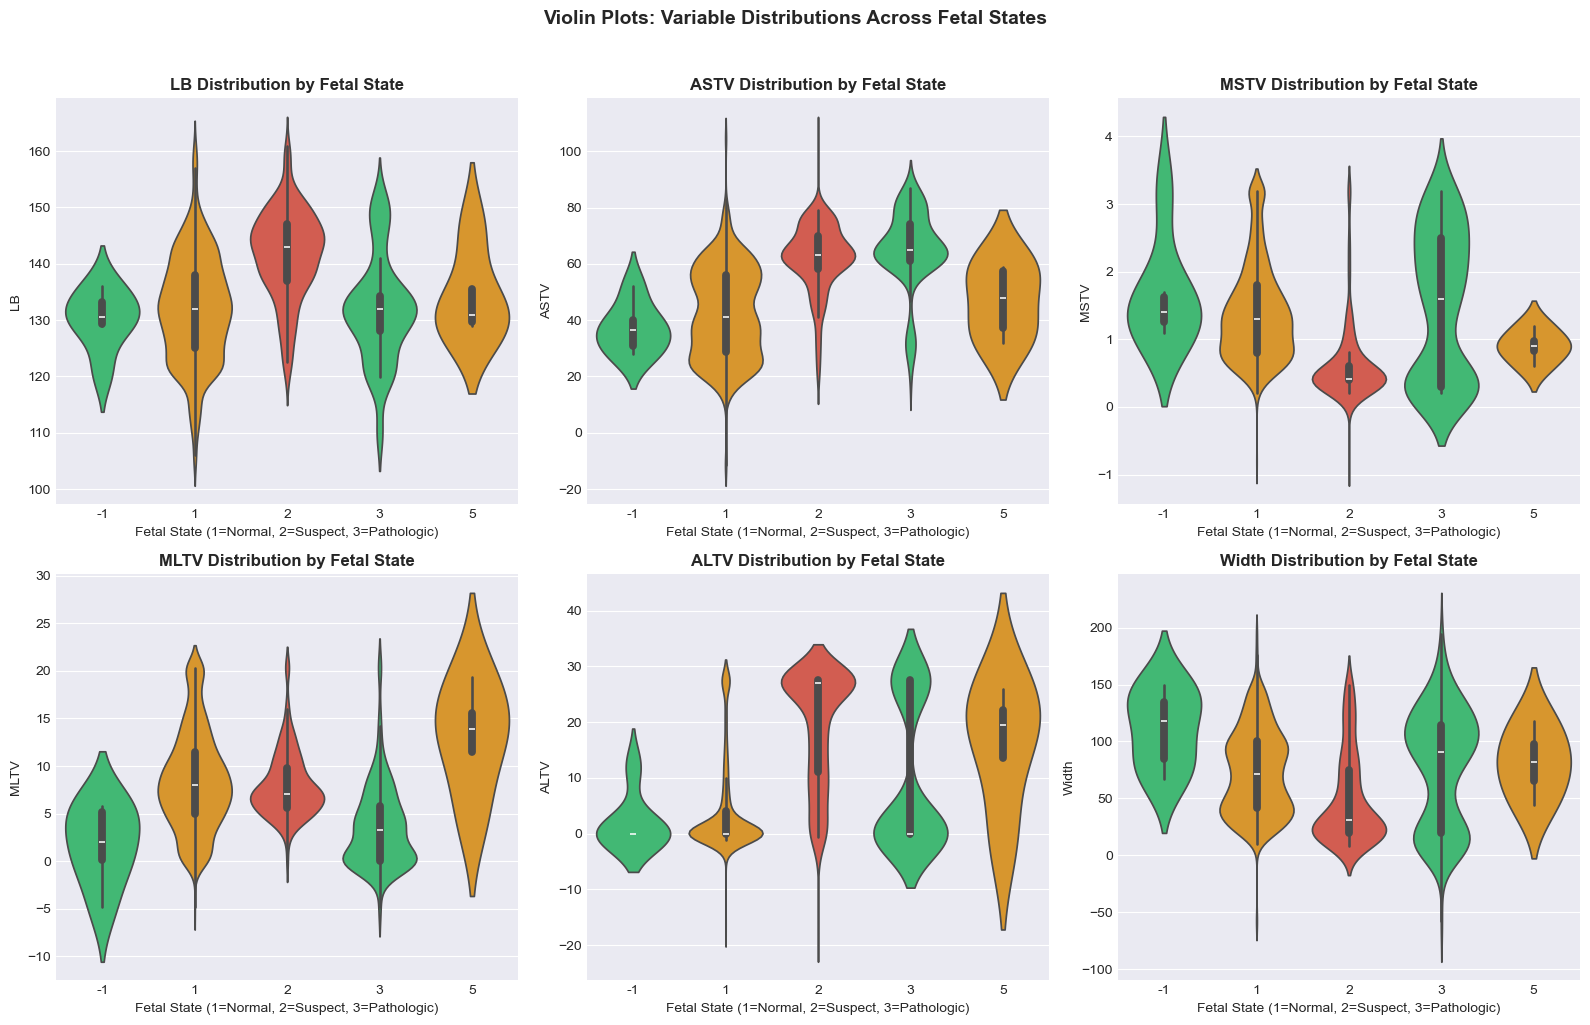

In [15]:
# Violin plots for key variables by NSP class
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

violin_vars = ['LB', 'ASTV', 'MSTV', 'MLTV', 'ALTV', 'Width']
for i, var in enumerate(violin_vars):
    sns.violinplot(data=df_clean, x='NSP', y=var, ax=axes[i], palette=colors)
    axes[i].set_title(f'{var} Distribution by Fetal State', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Fetal State (1=Normal, 2=Suspect, 3=Pathologic)')

plt.suptitle('Violin Plots: Variable Distributions Across Fetal States', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

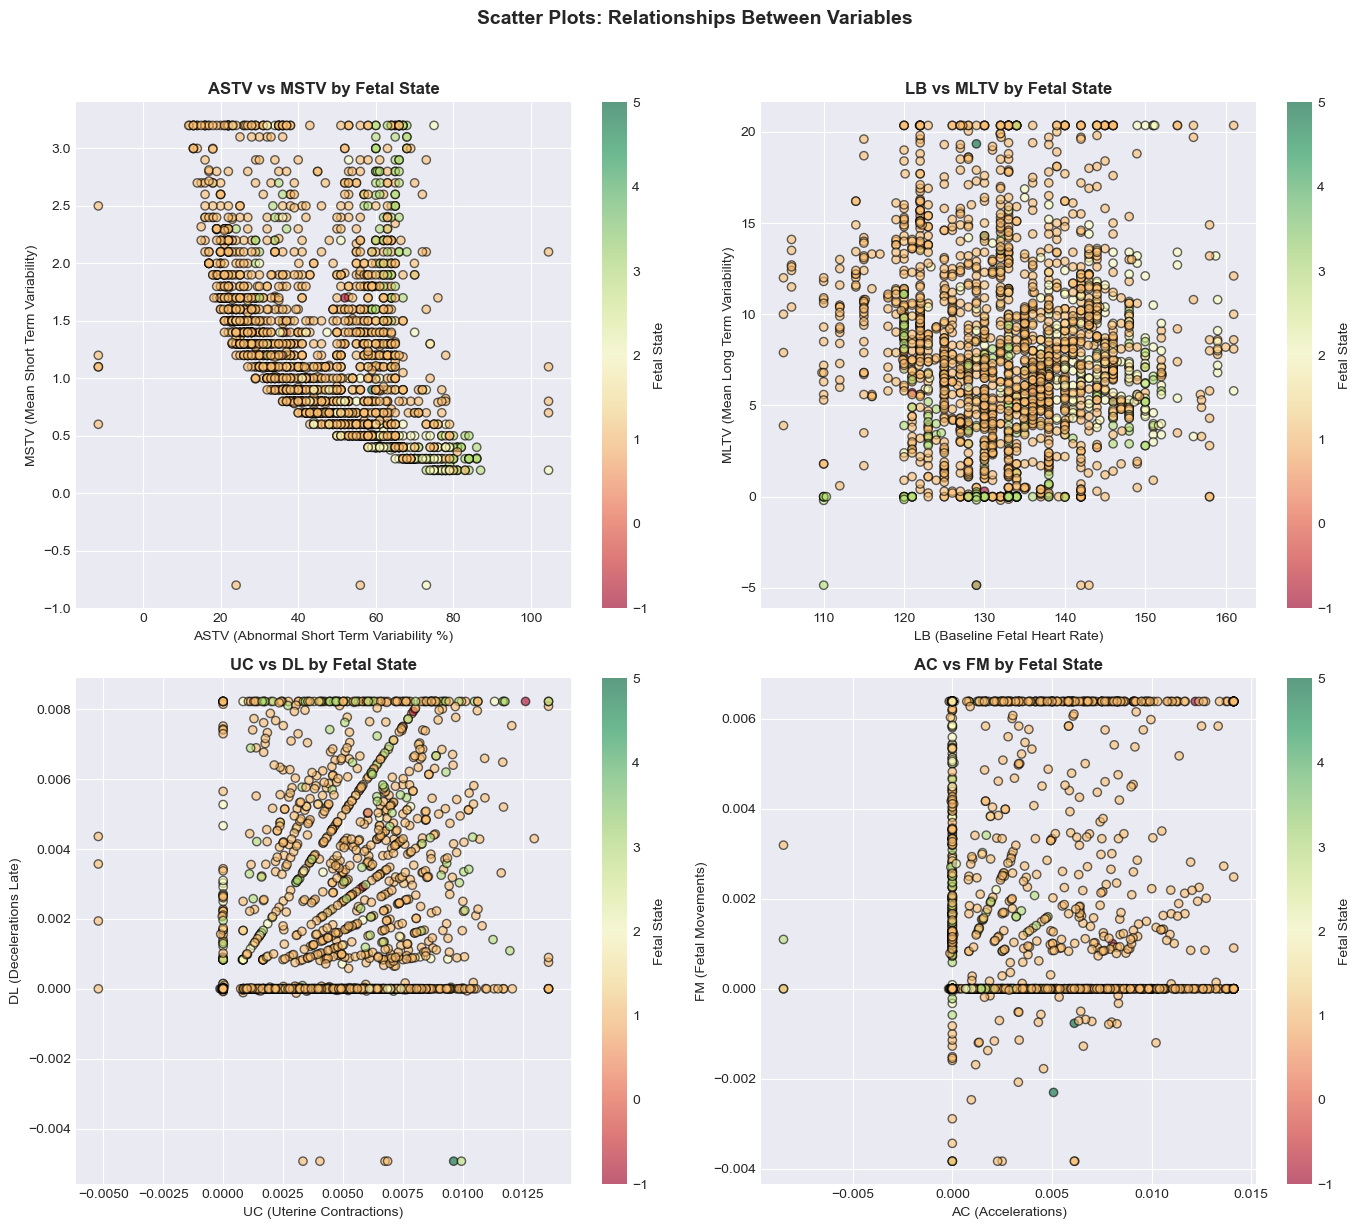

In [16]:
# Scatter plots for exploring relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Scatter 1: ASTV vs MSTV
scatter1 = axes[0,0].scatter(df_clean['ASTV'], df_clean['MSTV'], 
                              c=df_clean['NSP'], cmap='RdYlGn', alpha=0.6, edgecolors='black')
axes[0,0].set_xlabel('ASTV (Abnormal Short Term Variability %)')
axes[0,0].set_ylabel('MSTV (Mean Short Term Variability)')
axes[0,0].set_title('ASTV vs MSTV by Fetal State', fontweight='bold')
plt.colorbar(scatter1, ax=axes[0,0], label='Fetal State')

# Scatter 2: LB vs MLTV
scatter2 = axes[0,1].scatter(df_clean['LB'], df_clean['MLTV'], 
                              c=df_clean['NSP'], cmap='RdYlGn', alpha=0.6, edgecolors='black')
axes[0,1].set_xlabel('LB (Baseline Fetal Heart Rate)')
axes[0,1].set_ylabel('MLTV (Mean Long Term Variability)')
axes[0,1].set_title('LB vs MLTV by Fetal State', fontweight='bold')
plt.colorbar(scatter2, ax=axes[0,1], label='Fetal State')

# Scatter 3: UC vs DL
scatter3 = axes[1,0].scatter(df_clean['UC'], df_clean['DL'], 
                              c=df_clean['NSP'], cmap='RdYlGn', alpha=0.6, edgecolors='black')
axes[1,0].set_xlabel('UC (Uterine Contractions)')
axes[1,0].set_ylabel('DL (Decelerations Late)')
axes[1,0].set_title('UC vs DL by Fetal State', fontweight='bold')
plt.colorbar(scatter3, ax=axes[1,0], label='Fetal State')

# Scatter 4: AC vs FM
scatter4 = axes[1,1].scatter(df_clean['AC'], df_clean['FM'], 
                              c=df_clean['NSP'], cmap='RdYlGn', alpha=0.6, edgecolors='black')
axes[1,1].set_xlabel('AC (Accelerations)')
axes[1,1].set_ylabel('FM (Fetal Movements)')
axes[1,1].set_title('AC vs FM by Fetal State', fontweight='bold')
plt.colorbar(scatter4, ax=axes[1,1], label='Fetal State')

plt.suptitle('Scatter Plots: Relationships Between Variables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# Task 4: Pattern Recognition and Insights


# Find strongest correlations with NSP
nsp_corr = df_clean[numerical_cols + ['NSP']].corr()['NSP'].sort_values(ascending=False)
print("\nStrongest Correlations with Fetal State (NSP):")
print(nsp_corr.round(3))

# Find highest correlations between features (excluding NSP)
corr_matrix = df_clean[numerical_cols].corr()
# Mask the diagonal
np.fill_diagonal(corr_matrix.values, np.nan)
# Find top correlations
top_correlations = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        top_correlations.append({
            'Variable 1': corr_matrix.columns[i],
            'Variable 2': corr_matrix.columns[j],
            'Correlation': corr_matrix.iloc[i, j]
        })

top_correlations_df = pd.DataFrame(top_correlations)
top_correlations_df['Abs_Correlation'] = top_correlations_df['Correlation'].abs()
top_correlations_df = top_correlations_df.sort_values('Abs_Correlation', ascending=False).head(10)

print("\nTop 10 Strongest Correlations Between Variables:")
print(top_correlations_df[['Variable 1', 'Variable 2', 'Correlation']].round(3))


Strongest Correlations with Fetal State (NSP):
NSP         1.000
ASTV        0.450
ALTV        0.351
LB          0.147
FM          0.071
DL          0.013
Width      -0.073
Tendency   -0.113
MSTV       -0.130
MLTV       -0.199
UC         -0.202
AC         -0.350
DS            NaN
DP            NaN
Name: NSP, dtype: float64

Top 10 Strongest Correlations Between Variables:
   Variable 1 Variable 2  Correlation
70       MSTV      Width        0.650
45         DL       MSTV        0.566
68       MSTV       ALTV       -0.541
48         DL      Width        0.517
73       ALTV      Width       -0.441
64       ASTV       ALTV        0.439
63       ASTV       MSTV       -0.435
19         AC       ALTV       -0.410
65       ASTV       MLTV       -0.326
8          LB       ALTV        0.323


In [25]:
# 4.2 Class-based Statistical Analysis

# Group by NSP and calculate statistics
class_stats = df_clean.groupby('NSP')[numerical_cols].agg(['mean', 'median', 'std']).round(2)
print("Mean values by Fetal State Class:")
print(class_stats.xs('mean', axis=1, level=1))

# Calculate differences between classes
print("\nKey Differences Between Normal and Pathologic Classes:")
for col in numerical_cols:
    normal_mean = df_clean[df_clean['NSP'] == 1][col].mean()
    pathologic_mean = df_clean[df_clean['NSP'] == 3][col].mean()
    diff_pct = ((pathologic_mean - normal_mean) / normal_mean) * 100
    if abs(diff_pct) > 20:  # Only show differences > 20%
        print(f"  {col}: Pathologic is {diff_pct:+.1f}% different from Normal")

Mean values by Fetal State Class:
         LB    AC   FM    UC   DL   DS   DP   ASTV  MSTV   ALTV   MLTV  \
NSP                                                                      
-1   130.17  0.01  0.0  0.01  0.0  0.0  0.0  37.12  1.67   2.00   1.77   
 1   131.95  0.00  0.0  0.00  0.0  0.0  0.0  42.41  1.40   4.12   8.50   
 2   141.67  0.00  0.0  0.00  0.0  0.0  0.0  61.96  0.63  19.43   8.00   
 3   131.81  0.00  0.0  0.00  0.0  0.0  0.0  65.16  1.50   9.70   3.60   
 5   134.25  0.00  0.0  0.00 -0.0  0.0  0.0  46.75  0.90  16.25  13.08   

      Width  Tendency  
NSP                    
-1   111.17      0.33  
 1    73.14      0.34  
 2    49.33      0.44  
 3    77.63     -0.07  
 5    81.37      0.50  

Key Differences Between Normal and Pathologic Classes:
  AC: Pathologic is -90.9% different from Normal
  FM: Pathologic is +20.1% different from Normal
  UC: Pathologic is -21.9% different from Normal
  DL: Pathologic is +71.3% different from Normal
  ASTV: Pathologic is +53.6

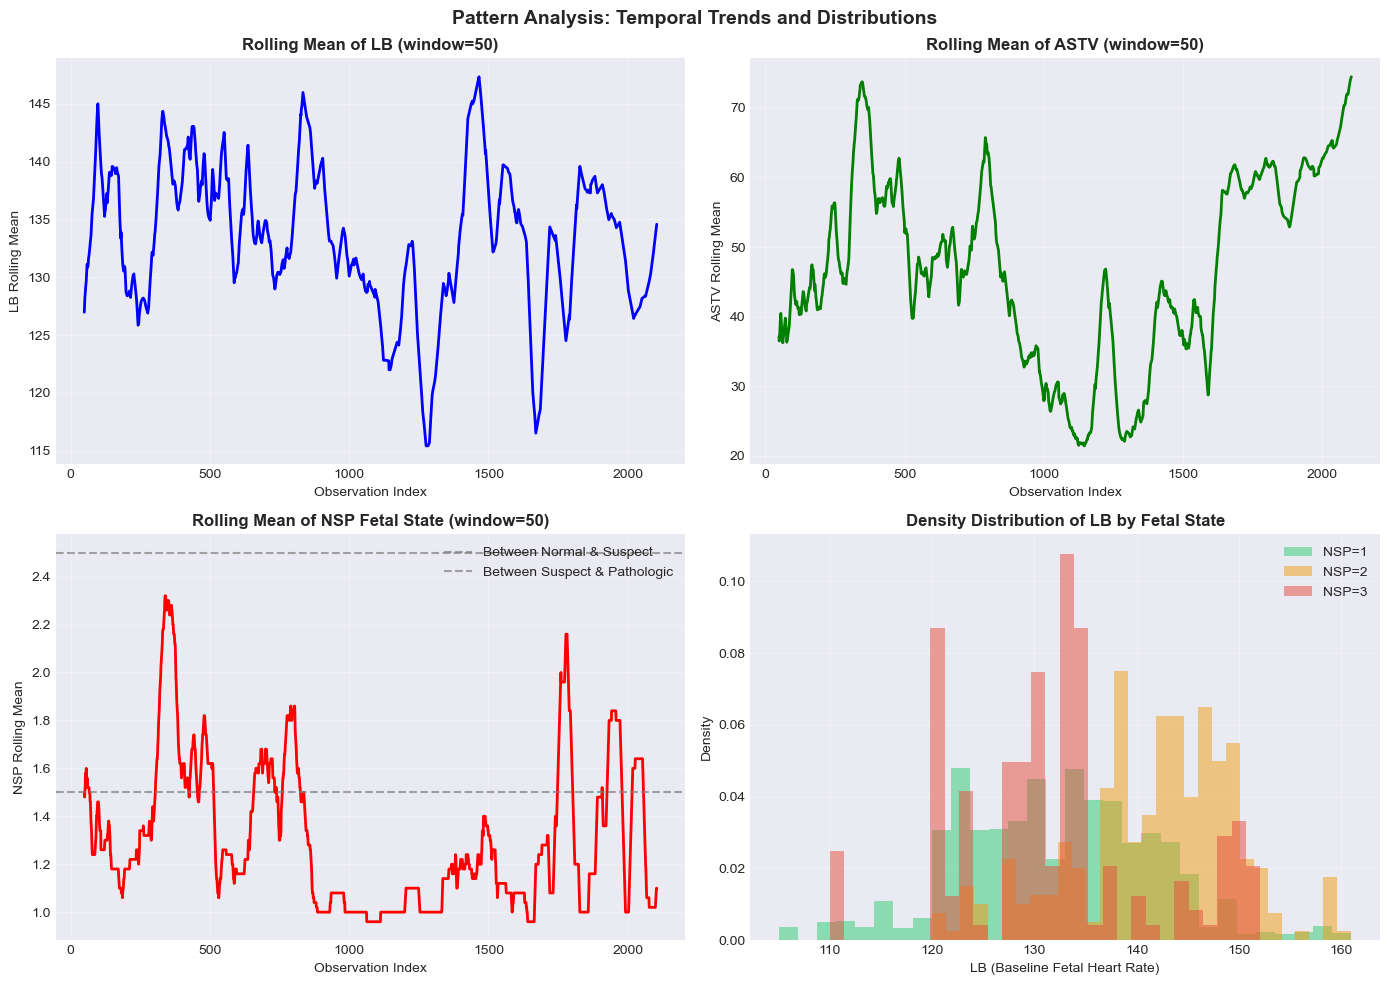

In [26]:
# 4.3 Temporal Pattern Analysis (if applicable)

# Check for patterns in the data (no explicit time column, but we can analyze ordering)
df_clean['Row_Index'] = range(len(df_clean))

# Analyze rolling means for key variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rolling mean for LB
window_size = 50
axes[0,0].plot(df_clean['Row_Index'], df_clean['LB'].rolling(window=window_size).mean(), 
               color='blue', linewidth=2)
axes[0,0].set_title(f'Rolling Mean of LB (window={window_size})', fontweight='bold')
axes[0,0].set_xlabel('Observation Index')
axes[0,0].set_ylabel('LB Rolling Mean')
axes[0,0].grid(True, alpha=0.3)

# Rolling mean for ASTV
axes[0,1].plot(df_clean['Row_Index'], df_clean['ASTV'].rolling(window=window_size).mean(), 
               color='green', linewidth=2)
axes[0,1].set_title(f'Rolling Mean of ASTV (window={window_size})', fontweight='bold')
axes[0,1].set_xlabel('Observation Index')
axes[0,1].set_ylabel('ASTV Rolling Mean')
axes[0,1].grid(True, alpha=0.3)

# NSP distribution over indexes
nsp_moving_avg = df_clean['NSP'].rolling(window=window_size).mean()
axes[1,0].plot(df_clean['Row_Index'], nsp_moving_avg, color='red', linewidth=2)
axes[1,0].axhline(y=1.5, color='gray', linestyle='--', alpha=0.7, label='Between Normal & Suspect')
axes[1,0].axhline(y=2.5, color='gray', linestyle='--', alpha=0.7, label='Between Suspect & Pathologic')
axes[1,0].set_title(f'Rolling Mean of NSP Fetal State (window={window_size})', fontweight='bold')
axes[1,0].set_xlabel('Observation Index')
axes[1,0].set_ylabel('NSP Rolling Mean')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Density plot of LB by NSP
for nsp_val, color in zip([1, 2, 3], colors):
    subset = df_clean[df_clean['NSP'] == nsp_val]['LB']
    axes[1,1].hist(subset, bins=30, alpha=0.5, label=f'NSP={nsp_val}', color=color, density=True)
axes[1,1].set_title('Density Distribution of LB by Fetal State', fontweight='bold')
axes[1,1].set_xlabel('LB (Baseline Fetal Heart Rate)')
axes[1,1].set_ylabel('Density')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Pattern Analysis: Temporal Trends and Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# 4.4 Feature Importance Analysis (simple ranking)

# Calculate feature importance based on correlation with NSP
feature_importance = pd.DataFrame({
    'Feature': nsp_corr.index,
    'Correlation_with_NSP': nsp_corr.values
})
feature_importance = feature_importance[feature_importance['Feature'] != 'NSP']
feature_importance['Abs_Correlation'] = feature_importance['Correlation_with_NSP'].abs()
feature_importance = feature_importance.sort_values('Abs_Correlation', ascending=False)

print("\nTop 10 Most Important Features for Classifying Fetal State:")
print(feature_importance.head(10)[['Feature', 'Correlation_with_NSP']].round(3))


Top 10 Most Important Features for Classifying Fetal State:
     Feature  Correlation_with_NSP
1       ASTV                 0.450
2       ALTV                 0.351
11        AC                -0.350
10        UC                -0.202
9       MLTV                -0.199
3         LB                 0.147
8       MSTV                -0.130
7   Tendency                -0.113
6      Width                -0.073
4         FM                 0.071


In [28]:
# 4.5 Advanced Pattern: Cluster-like behavior

# Identify which features best separate Normal vs Pathologic
print("Features that best differentiate between Normal and Pathologic states:")

threshold = 0.2
for _, row in feature_importance.head(10).iterrows():
    feature = row['Feature']
    corr_value = row['Correlation_with_NSP']
    
    # Calculate class means
    class1_mean = df_clean[df_clean['NSP'] == 1][feature].mean()
    class3_mean = df_clean[df_clean['NSP'] == 3][feature].mean()
    
    if corr_value > 0:
        direction = "INCREASES"
    else:
        direction = "DECREASES"
    
    print(f"  • {feature}: Correlation={corr_value:.3f} - Pathologic state {direction} from Normal")
    print(f"    (Normal: {class1_mean:.2f}, Pathologic: {class3_mean:.2f})")

Features that best differentiate between Normal and Pathologic states:
  • ASTV: Correlation=0.450 - Pathologic state INCREASES from Normal
    (Normal: 42.41, Pathologic: 65.16)
  • ALTV: Correlation=0.351 - Pathologic state INCREASES from Normal
    (Normal: 4.12, Pathologic: 9.70)
  • AC: Correlation=-0.350 - Pathologic state DECREASES from Normal
    (Normal: 0.00, Pathologic: 0.00)
  • UC: Correlation=-0.202 - Pathologic state DECREASES from Normal
    (Normal: 0.00, Pathologic: 0.00)
  • MLTV: Correlation=-0.199 - Pathologic state DECREASES from Normal
    (Normal: 8.50, Pathologic: 3.60)
  • LB: Correlation=0.147 - Pathologic state INCREASES from Normal
    (Normal: 131.95, Pathologic: 131.81)
  • MSTV: Correlation=-0.130 - Pathologic state DECREASES from Normal
    (Normal: 1.40, Pathologic: 1.50)
  • Tendency: Correlation=-0.113 - Pathologic state DECREASES from Normal
    (Normal: 0.34, Pathologic: -0.07)
  • Width: Correlation=-0.073 - Pathologic state DECREASES from Normal


In [ ]:
# Task 5: Conclusion and Summary Report

1. DATASET OVERVIEW:
   - Total samples analyzed: {total_samples}
   - Numerical variables: {num_vars}
   - Target variable (NSP): 3 classes (1=Normal, 2=Suspect, 3=Pathologic)
   - Class distribution: {dist_normal}% Normal, {dist_suspect}% Suspect, {dist_pathologic}% Pathologic

2. KEY STATISTICAL FINDINGS:
   - Highly skewed variables: {skewed_vars}
   - Variables with high variance: {high_var_vars}
   - Negative values present in: {negative_cols_list}

3. CORRELATION INSIGHTS:
   - Strongest positive correlation with NSP: {top_pos_corr}
   - Strongest negative correlation with NSP: {top_neg_corr}
   - Highest feature-feature correlation: {top_feature_pair}

4. CLASS SEPARATION PATTERNS:
   - Pathologic cases show {lb_trend} Baseline Fetal Heart Rate compared to Normal
   - ASTV (Abnormal Short Term Variability) {astv_trend} in Pathologic cases
   - MLTV (Mean Long Term Variability) {mltv_trend} in Pathologic cases

5. DATA QUALITY OBSERVATIONS:
   - Missing values ratio: {missing_ratio:.2%}
   - Outliers detected and capped using IQR method
   - Negative values present in some columns (potential data entry issues)

6. RECOMMENDATIONS:
   a) Further Analysis:
      - Build classification models to predict fetal distress
      - Investigate temporal patterns more deeply
      - Consider feature engineering for better class separation
   
   b) Clinical Implications:
      - ASTV, MLTV, and LB are strong indicators of fetal state
      - Monitor variable combinations rather than single indicators
      - Suspect cases (NSP=2) show intermediate patterns
   
   c) Data Improvements:
      - Investigate source of negative values
      - Consider collecting additional clinical variables
      - Implement regular data quality checks